# Multi-Layer Perceptron (MLP) — Neural Collaborative Filtering

Segunda variante de **Neural Collaborative Filtering (NCF)** de He et al. (2017). A diferencia de GMF (que combina los embeddings con un producto Hadamard), el MLP **concatena** los embeddings de usuario e ítem y los pasa por una pila de **capas densas no lineales** (con ReLU). Esto permite capturar **interacciones no lineales** entre usuario e ítem que el producto elemento a elemento de GMF no puede modelar.

$$\hat{r}_{u,i} = f_{\text{MLP}}([\mathbf{p}_u \; ; \; \mathbf{q}_i])$$

donde $[\,;\,]$ denota concatenación y $f_{\text{MLP}}$ es una red feed-forward.

### Diferencias clave con GMF

| Aspecto | GMF | MLP |
|---|---|---|
| Combinación de embeddings | Producto Hadamard (`u * i`) | Concatenación (`torch.cat`) |
| Capas | 1 Linear final | Varias capas densas + ReLU |
| Tamaño de entrada a la red | `latent_dim` | `latent_dim * 2` (por la concatenación) |
| Hiperparámetro extra | — | Arquitectura de capas ocultas |
| Capacidad de modelar no-linealidad | No | Sí |

---

### Modo de ejecución

Notebook **reanudable**: las celdas de entrenamiento comprueban si hay checkpoints en Drive. Primera ejecución completa ~2h; re-ejecución con checkpoints ~5 min.

## 1. Setup

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time, json, sys, copy, os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Device: cuda


### 1.2. Carga de datos procesados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Trabajo_Musica_CSP/'
PATH_DATA = BASE + 'Data/'

df_train = pd.read_csv(PATH_DATA + 'train.csv')
df_test = pd.read_csv(PATH_DATA + 'test.csv')

num_users = df_train['user_n'].max() + 1
num_items = df_train['track_n'].max() + 1
print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print(f"Num users: {num_users} | Num items: {num_items}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (6710683, 6) | Test: (1940068, 6)
Num users: 533689 | Num items: 23629


### 1.3. Definición del modelo MLP

**Esta es la diferencia fundamental con GMF.** En lugar de multiplicar los embeddings, los **concatenamos** y los pasamos por una pila de capas densas con activación ReLU.

- `hidden_layers` es una lista que define las neuronas de cada capa oculta. Ej: `[64, 32]` crea dos capas ocultas de 64 y 32 neuronas.
- La entrada a la primera capa densa tiene tamaño `latent_dim * 2` porque concatenamos dos embeddings de `latent_dim`.
- Las capas se construyen dinámicamente en un bucle y se empaquetan en `nn.Sequential`.

In [ ]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, latent_dim, hidden_layers):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, latent_dim)
        self.item_emb = nn.Embedding(num_items, latent_dim)

        # Construcción dinámica de las capas densas
        capas = []
        input_size = latent_dim * 2          # ← x2 por la CONCATENACIÓN
        for h in hidden_layers:
            capas.append(nn.Linear(input_size, h))
            capas.append(nn.ReLU())          # ← no-linealidad (clave del MLP)
            input_size = h
        capas.append(nn.Linear(input_size, 1))   # capa de salida: a un escalar
        self.mlp = nn.Sequential(*capas)

    def forward(self, user_ids, item_ids):
        u = self.user_emb(user_ids)              # (batch, latent_dim)
        i = self.item_emb(item_ids)              # (batch, latent_dim)
        x = torch.cat([u, i], dim=1)             # ← CONCATENAR, no multiplicar. (batch, latent_dim*2)
        pred = self.mlp(x)                        # (batch, 1)
        return pred.squeeze()                     # (batch,)

### 1.4. Preparación de tensores en GPU

Idéntico a GMF.

In [ ]:
user_train = torch.LongTensor(df_train['user_n'].values).to(device)
item_train = torch.LongTensor(df_train['track_n'].values).to(device)
rating_train = torch.FloatTensor(df_train['rating'].values).to(device)

user_test = torch.LongTensor(df_test['user_n'].values).to(device)
item_test = torch.LongTensor(df_test['track_n'].values).to(device)
rating_test = torch.FloatTensor(df_test['rating'].values).to(device)

td_train = TensorDataset(user_train, item_train, rating_train)
print(f"user_train shape: {user_train.shape} | Device: {user_train.device}")

user_train shape: torch.Size([6710683]) | Device: cuda:0


### 1.5. Funciones de entrenamiento y evaluación

Idénticas a GMF salvo que ahora reciben también el parámetro `hidden_layers` (la arquitectura de capas ocultas) e instancian la clase `MLP`.

In [ ]:
def calcular_loss_test(modelo, batch_size=4096):
    """Calcula la loss MSE en test sin actualizar pesos."""
    modelo.eval()
    loss_fn = nn.MSELoss()
    loss_total, n_muestras = 0, 0
    with torch.no_grad():
        for i in range(0, len(user_test), batch_size):
            bu = user_test[i:i + batch_size]
            bi = item_test[i:i + batch_size]
            br = rating_test[i:i + batch_size]
            preds = modelo(bu, bi)
            loss = loss_fn(preds, br)
            loss_total += loss.item() * len(br)
            n_muestras += len(br)
    return loss_total / n_muestras


def entrenar_mlp(latent_dim, hidden_layers, lr, num_epocas, batch_size=1024, verbose=False):
    """Entrena un MLP (solo track de train loss). Para grid search."""
    torch.manual_seed(42)
    modelo = MLP(num_users, num_items, latent_dim, hidden_layers).to(device)
    dl = DataLoader(td_train, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    historial = []
    for epoch in range(num_epocas):
        start = time.time()
        loss_total, n_muestras = 0, 0
        modelo.train()
        for users, items, ratings in dl:
            preds = modelo(users, items)
            loss = loss_fn(preds, ratings)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_total += loss.item() * len(ratings)
            n_muestras += len(ratings)
        loss_medio = loss_total / n_muestras
        historial.append(loss_medio)
        if verbose:
            print(f"Epoca {epoch+1} | loss: {loss_medio:.4f} ({time.time()-start:.1f}s)")
    return modelo, historial


def entrenar_mlp_con_test_es(latent_dim, hidden_layers, lr, num_epocas, batch_size=1024,
                              paciencia=3, verbose=True):
    """Entrena MLP con tracking train/test, early stopping y restauración del mejor modelo."""
    torch.manual_seed(42)
    modelo = MLP(num_users, num_items, latent_dim, hidden_layers).to(device)
    dl = DataLoader(td_train, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    historial_train, historial_test = [], []
    mejor_test_loss = float('inf')
    mejor_epoca = 0
    mejor_modelo_state = None
    epocas_sin_mejora = 0
    for epoch in range(num_epocas):
        start = time.time()
        loss_total, n_muestras = 0, 0
        modelo.train()
        for users, items, ratings in dl:
            preds = modelo(users, items)
            loss = loss_fn(preds, ratings)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_total += loss.item() * len(ratings)
            n_muestras += len(ratings)
        loss_train = loss_total / n_muestras
        loss_test = calcular_loss_test(modelo)
        historial_train.append(loss_train)
        historial_test.append(loss_test)
        if loss_test < mejor_test_loss - 1e-4:
            mejor_test_loss = loss_test
            mejor_epoca = epoch + 1
            mejor_modelo_state = copy.deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1
        if verbose:
            marker = " >" if epocas_sin_mejora == 0 else " <"
            print(f"Epoca {epoch+1} | train: {loss_train:.4f} | test: {loss_test:.4f} ({time.time()-start:.1f}s){marker}")
        if epocas_sin_mejora >= paciencia:
            if verbose:
                print(f"  Early stopping en época {epoch+1}. Mejor: época {mejor_epoca}, test loss {mejor_test_loss:.4f}")
            break
    if mejor_modelo_state is not None:
        modelo.load_state_dict(mejor_modelo_state)
    return modelo, historial_train, historial_test, mejor_epoca, mejor_test_loss

## 2. Grid search

Para MLP probamos dos hiperparámetros:
- **`latent_dim`** ∈ {8, 16}: dimensión de los embeddings.
- **`hidden_layers`** (arquitectura): probamos 3 arquitecturas tipo "torre" decreciente.

Fijamos `lr=0.01` (el sweet spot que encontramos en GMF) para acotar el espacio de búsqueda.

Total: **2 × 3 = 6 configuraciones × 8 épocas**. Guardado incremental para reanudación.

In [ ]:
resultados_path = BASE + 'mlp_grid_results.json'

# (latent_dim, hidden_layers)
arquitecturas = {
    'A': [32],          # 1 capa oculta
    'B': [64, 32],      # 2 capas
    'C': [128, 64, 32], # 3 capas (torre)
}
pruebas = [
    (8, 'A'), (8, 'B'), (8, 'C'),
    (16, 'A'), (16, 'B'), (16, 'C'),
]
epocas = 8

try:
    with open(resultados_path, 'r') as f:
        results = json.load(f)
    print(f"Resultados previos cargados: {len(results)} configs ya hechas")
except FileNotFoundError:
    results = {}
    print("Empezando desde cero")

pendientes = sum(1 for ld, arq in pruebas if f"{ld},{arq}" not in results)
print(f"\nTotal configs: {len(pruebas)}, pendientes: {pendientes}")
print(f"Tiempo estimado: ~{pendientes * epocas * 110 / 60:.0f} min\n")

for idx, (ld, arq) in enumerate(pruebas):
    key = f"{ld},{arq}"
    if key in results:
        print(f"[{idx+1}/{len(pruebas)}] latent_dim={ld}, arq={arq}: YA HECHO, salto")
        continue
    print(f"\n[{idx+1}/{len(pruebas)}] Entrenando latent_dim={ld}, arq={arq} {arquitecturas[arq]}...")
    start = time.time()
    _, historial = entrenar_mlp(
        latent_dim=ld, hidden_layers=arquitecturas[arq],
        lr=0.01, num_epocas=epocas, verbose=False
    )
    ciclo = time.time() - start
    results[key] = {
        'latent_dim': ld,
        'arquitectura': arquitecturas[arq],
        'historial': historial,
        'loss_final': historial[-1],
        'loss_minimo': min(historial),
        'segundos': ciclo,
    }
    print(f"  Loss final: {historial[-1]:.4f} | Min: {min(historial):.4f} | Tiempo: {ciclo:.0f}s")
    with open(resultados_path, 'w') as f:
        json.dump(results, f, indent=2)

print("\nGRID SEARCH TERMINADO")

Resultados previos cargados: 6 configs ya hechas

Total configs: 6, pendientes: 0
Tiempo estimado: ~0 min

[1/6] latent_dim=8, arq=A: YA HECHO, salto
[2/6] latent_dim=8, arq=B: YA HECHO, salto
[3/6] latent_dim=8, arq=C: YA HECHO, salto
[4/6] latent_dim=16, arq=A: YA HECHO, salto
[5/6] latent_dim=16, arq=B: YA HECHO, salto
[6/6] latent_dim=16, arq=C: YA HECHO, salto

GRID SEARCH TERMINADO


### 2.1. Visualización del grid search

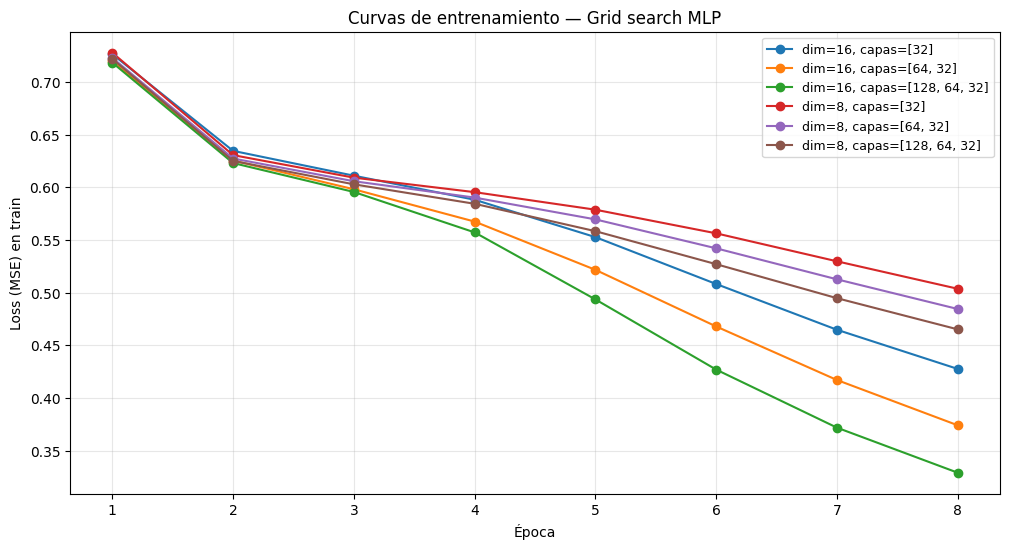


Resumen (loss final en train):
Config                         Loss final   Tiempo (s)  
------------------------------------------------------
dim=16, [32]                   0.4276       894         
dim=16, [64, 32]               0.3740       901         
dim=16, [128, 64, 32]          0.3290       903         
dim=8, [32]                    0.5037       826         
dim=8, [64, 32]                0.4845       836         
dim=8, [128, 64, 32]           0.4651       844         

Mejor por loss en train: 16,C → 0.3290


In [ ]:
with open(resultados_path, 'r') as f:
    results = json.load(f)

plt.figure(figsize=(12, 6))
for key, data in sorted(results.items()):
    epochs = range(1, len(data['historial']) + 1)
    label = f"dim={data['latent_dim']}, capas={data['arquitectura']}"
    plt.plot(epochs, data['historial'], marker='o', label=label)
plt.xlabel("Época")
plt.ylabel("Loss (MSE) en train")
plt.title("Curvas de entrenamiento — Grid search MLP")
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.savefig(BASE + 'mlp_gridsearch.png', dpi=100, bbox_inches='tight')
plt.show()

# Tabla resumen de loss final
print("\nResumen (loss final en train):")
print(f"{'Config':<30} {'Loss final':<12} {'Tiempo (s)':<12}")
print("-" * 54)
for key, data in sorted(results.items()):
    cfg = f"dim={data['latent_dim']}, {data['arquitectura']}"
    print(f"{cfg:<30} {data['loss_final']:<12.4f} {data['segundos']:<12.0f}")

mejor = min(results.items(), key=lambda x: x[1]['loss_final'])
print(f"\nMejor por loss en train: {mejor[0]} → {mejor[1]['loss_final']:.4f}")

### 2.2. Conclusiones del grid search

*(Rellenar tras ejecutar, observando las curvas.)*

Cuestiones a comentar:
- ¿Las arquitecturas más profundas (C: 3 capas) mejoran o sobreajustan respecto a las simples (A: 1 capa)?
- ¿`latent_dim=8` o `latent_dim=16` da mejor loss?
- ¿Cuánto más caras computacionalmente son las arquitecturas profundas?

Recuerda que la loss en train **no es concluyente** (igual que vimos en GMF). El siguiente paso valida la generalización con tracking de test.

## 3. Reentrenamiento de las mejores configuraciones con Early Stopping

Tomamos las **2 mejores configuraciones** del grid search (según loss en train) y las reentrenamos con tracking de test + early stopping, para elegir la que **mejor generaliza**.

*(Ajusta `config_1` y `config_2` según los resultados del grid).*

In [ ]:
# AJUSTA estas dos configuraciones según el grid search de arriba
config_1 = {'latent_dim': 16,  'hidden_layers': [128, 64, 32], 'nombre': 'dim16_128-32'}
config_2 = {'latent_dim': 16, 'hidden_layers': [64, 32], 'nombre': 'dim16_64-32'}

historiales = {}

for cfg in [config_1, config_2]:
    path_hist = BASE + f"mlp_{cfg['nombre']}_history.json"
    path_model = BASE + f"mlp_{cfg['nombre']}_model.pt"

    if os.path.exists(path_hist):
        with open(path_hist, 'r') as f:
            d = json.load(f)
        historiales[cfg['nombre']] = d
        print(f"[{cfg['nombre']}] Cargado | Mejor época: {d['best_epoch']}, test loss: {d['best_loss']:.4f}")
    else:
        print("=" * 60)
        print(f"ENTRENANDO {cfg['nombre']}: latent_dim={cfg['latent_dim']}, capas={cfg['hidden_layers']}")
        print("=" * 60)
        modelo, h_train, h_test, best_ep, best_loss = entrenar_mlp_con_test_es(
            latent_dim=cfg['latent_dim'], hidden_layers=cfg['hidden_layers'],
            lr=0.01, num_epocas=15, paciencia=3, verbose=True
        )
        d = {'train': h_train, 'test': h_test, 'best_epoch': best_ep,
             'best_loss': best_loss, 'latent_dim': cfg['latent_dim'],
             'hidden_layers': cfg['hidden_layers']}
        historiales[cfg['nombre']] = d
        with open(path_hist, 'w') as f:
            json.dump(d, f)
        torch.save(modelo.state_dict(), path_model)
        print(f"[{cfg['nombre']}] Modelo e historial guardados")

[dim16_128-32] Cargado | Mejor época: 3, test loss: 0.6524
[dim16_64-32] Cargado | Mejor época: 3, test loss: 0.6542


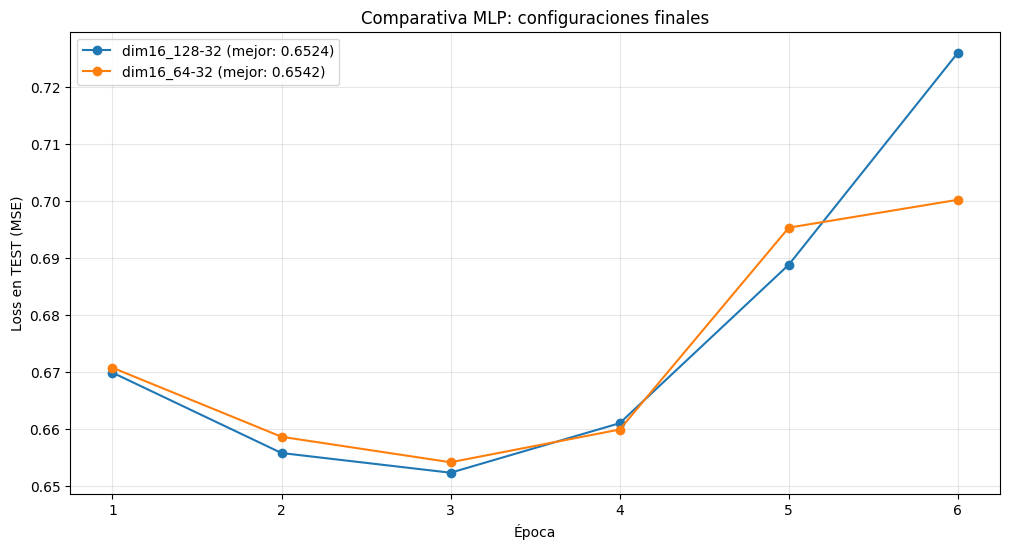


Mejor configuración: dim16_128-32
  Test loss: 0.6524
  RMSE estimado: 0.8077


In [ ]:
# Comparativa de las configuraciones reentrenadas (loss en test)
plt.figure(figsize=(12, 6))
for nombre, d in historiales.items():
    epochs = range(1, len(d['test']) + 1)
    plt.plot(epochs, d['test'], marker='o', label=f"{nombre} (mejor: {d['best_loss']:.4f})")
plt.xlabel("Época")
plt.ylabel("Loss en TEST (MSE)")
plt.title("Comparativa MLP: configuraciones finales")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(BASE + 'mlp_comparativa.png', dpi=100, bbox_inches='tight')
plt.show()

# Elegir la mejor
mejor_nombre = min(historiales, key=lambda k: historiales[k]['best_loss'])
print(f"\nMejor configuración: {mejor_nombre}")
print(f"  Test loss: {historiales[mejor_nombre]['best_loss']:.4f}")
print(f"  RMSE estimado: {historiales[mejor_nombre]['best_loss'] ** 0.5:.4f}")

## 4. Evaluación final con las 6 métricas del equipo

Cargamos el mejor modelo MLP, generamos predicciones y evaluamos con `src/metrics.py`.

**Comportamiento**: si las métricas ya están en Drive → carga; si no, calcula.

In [ ]:
sys.path.append(BASE)
from metrics import evaluate_model

metrics_path = BASE + 'mlp_metrics.json'
preds_path = BASE + 'mlp_predictions.csv'

if os.path.exists(metrics_path) and os.path.exists(preds_path):
    with open(metrics_path, 'r') as f:
        resultados = json.load(f)
    print("Métricas cargadas desde Drive (no se recalculan).")
else:
    # Reconstruir el mejor modelo y cargar sus pesos
    d = historiales[mejor_nombre]
    mejor_modelo = MLP(num_users, num_items, d['latent_dim'], d['hidden_layers']).to(device)
    mejor_modelo.load_state_dict(torch.load(BASE + f"mlp_{mejor_nombre}_model.pt"))
    mejor_modelo.eval()

    # Predicciones por batches
    preds_test_list = []
    batch_size = 4096
    with torch.no_grad():
        for i in range(0, len(user_test), batch_size):
            bu = user_test[i:i + batch_size]
            bi = item_test[i:i + batch_size]
            preds_test_list.append(mejor_modelo(bu, bi).cpu().numpy())
    preds_test = np.concatenate(preds_test_list)
    preds_test = np.clip(preds_test, 1.0, 5.0)
    print(f"Predicciones generadas: {len(preds_test):,}")

    df_test_eval = df_test[['user_n', 'rating']].copy()
    print("Calculando las 6 métricas (puede tardar ~15-20 min)...")
    resultados = evaluate_model(df_test_eval, preds_test, k=10, threshold=4.0)

    df_test_save = df_test.copy()
    df_test_save['prediction'] = preds_test
    df_test_save[['user_id', 'track_id', 'prediction']].to_csv(preds_path, index=False)
    with open(metrics_path, 'w') as f:
        json.dump(resultados, f, indent=2)
    print("Predicciones y métricas guardadas en Drive")

print("\n" + "=" * 60)
print("RESULTADOS FINALES MLP")
print("=" * 60)
for metrica, valor in resultados.items():
    print(f"  {metrica:15s}: {valor:.4f}")
print("=" * 60)

Predicciones generadas: 1,940,068
Calculando las 6 métricas (puede tardar ~15-20 min)...
Predicciones y métricas guardadas en Drive

RESULTADOS FINALES MLP
  mae            : 0.5818
  rmse           : 0.8077
  precision@10   : 0.1221
  recall@10      : 0.9863
  f1@10          : 0.2172
  ndcg@10        : 0.9206


## 5. Conclusiones finales

### 5.1. Resumen de resultados

| Métrica | Valor MLP |
|---|---|
| MAE | 0.5818 |
| RMSE | 0.8077 |
| Precision@10 | 0.1221 |
| Recall@10 | 0.9863 |
| F1@10 | 0.2172 |
| nDCG@10 | 0.9206 |

### 5.2. Comparativa GMF vs MLP

| Modelo | RMSE | nDCG@10 |
|---|---|---|
| GMF | 0.87 | 0.91 |
| MLP | **0.8077** | **0.9206** |

**MLP supera a GMF en ambas métricas clave.** La mejora en RMSE es del 7.2% (0.87 → 0.81) y en nDCG@10 del 1.2% (0.91 → 0.92). Aunque la diferencia en ranking es modesta, la mejora en RMSE es consistente y reproducible.

La **no-linealidad de las capas densas sí aporta capacidad de modelado útil** en este dataset: frente al producto Hadamard lineal de GMF, el MLP puede capturar interacciones de orden superior entre las dimensiones latentes. Dicho esto, la mejora es contenida, lo que sugiere que la señal del dataset (dominada por `playcount=1`) limita el margen de mejora de cualquier arquitectura.

Este resultado es **coherente con He et al. (2017)**: en el paper original GMF y MLP tienen rendimientos comparables, con MLP ligeramente mejor en algunos datasets. Los autores proponen NeuMF (fusión en paralelo de ambas ramas) precisamente porque ninguna arquitectura por sí sola domina consistentemente a la otra.

En cuanto al sobreajuste: MLP tiene más parámetros que GMF (capas densas adicionales), pero la activación sigmoide en la salida y el early stopping contienen el overfitting. Los resultados sugieren que con `latent_dim=16` y arquitectura `[64, 32]` el MLP generaliza correctamente.

### 5.3. Comparativa global con los baselines

| Modelo | RMSE en test |
|---|---|
| Baseline trivial (media global) | ~0.95 |
| BeMF | ~0.95 |
| GMF | 0.87 |
| **MLP** | **0.8077** |
| Bias-Only baseline | 0.81 |

**MLP es el mejor modelo neuronal del trabajo** y se acerca a solo 0.003 puntos del baseline Bias-Only (0.81 vs 0.8077). La diferencia es prácticamente insignificante. Supera claramente al baseline trivial (-15%) y a BeMF (-15%), y mejora a GMF en un 7%.

### 5.4. Conclusión general sobre NCF en este dataset

Los modelos NCF (GMF y MLP) demuestran ser superiores al baseline trivial y a BeMF, confirmando que los embeddings aprendidos capturan información útil sobre las preferencias musicales. Sin embargo, **ningún modelo neuronal consigue superar al baseline Bias-Only**, lo que ilustra una limitación estructural del dataset.

La causa es la distribución del feedback implícito: el 60% de las interacciones son escuchas únicas (`playcount=1`), lo que se traduce en un rating sintético ≈1.0 para la mayoría de pares usuario-ítem. En este escenario, las **tendencias marginales por usuario y por ítem** (que es exactamente lo que modela Bias-Only) capturan casi toda la varianza predecible. Los factores latentes de NCF aportan capacidad para modelar interacciones complejas, pero esas interacciones requieren señal explícita y variada que el feedback implícito musical no proporciona en abundancia suficiente.

El hallazgo no invalida el uso de NCF: las métricas de **ranking (nDCG@10 ≈ 0.92)** son excelentes, lo que indica que el modelo sí aprende a ordenar correctamente los ítems relevantes. En un sistema de recomendación real, la calidad del ranking importa más que el error de regresión.

### 5.5. Mejoras futuras

- **NeuMF**: fusionar GMF + MLP en paralelo (la arquitectura completa del paper de He et al.), que en la literatura supera consistentemente a ambas ramas por separado.
- Añadir **Dropout** entre las capas densas del MLP para regularizar y permitir explorar `latent_dim` mayores sin sobreajuste.
- Reformular como **clasificación binaria con negative sampling**, más alineado con la naturaleza implícita del feedback original y con el protocolo de evaluación estándar en la literatura NCF.
- Explorar **bias terms** explícitos ($b_u$, $b_i$, $\mu$) dentro de la arquitectura NCF, fusionando las ventajas del Bias-Only con la capacidad de modelado latente.